Multiple Linear Regression Analysis - Toyota Corolla Price Prediction
Complete Google Colab Implementation

In [3]:
#https://drive.google.com/file/d/1w8PfT8tC43BERGv44jECdzXq5XCCynkz/view?usp=sharing
file_id="1w8PfT8tC43BERGv44jECdzXq5XCCynkz"
url=f"https://drive.google.com/uc?id={file_id}"
df= pd.read_csv(url)


In [4]:
# ============================================================================
# STEP 1: Import Required Libraries
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# ============================================================================
# STEP 2: Load and Explore the Dataset
# ============================================================================
# Upload the CSV file in Colab

# Load the dataset
df = pd.read_csv(url)

print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Records: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

print("\n" + "-"*80)
print("First 5 Records:")
print("-"*80)
print(df.head())

print("\n" + "-"*80)
print("Dataset Information:")
print("-"*80)
print(df.info())

print("\n" + "-"*80)
print("Statistical Summary:")
print("-"*80)
print(df.describe())

print("\n" + "-"*80)
print("Missing Values:")
print("-"*80)
print(df.isnull().sum())



DATASET OVERVIEW

Dataset Shape: (1436, 11)
Number of Records: 1436
Number of Features: 11

--------------------------------------------------------------------------------
First 5 Records:
--------------------------------------------------------------------------------
   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  

--------------------------------------------------------------------------------
Dataset Information:
------------------------------------


EXPLORATORY DATA ANALYSIS


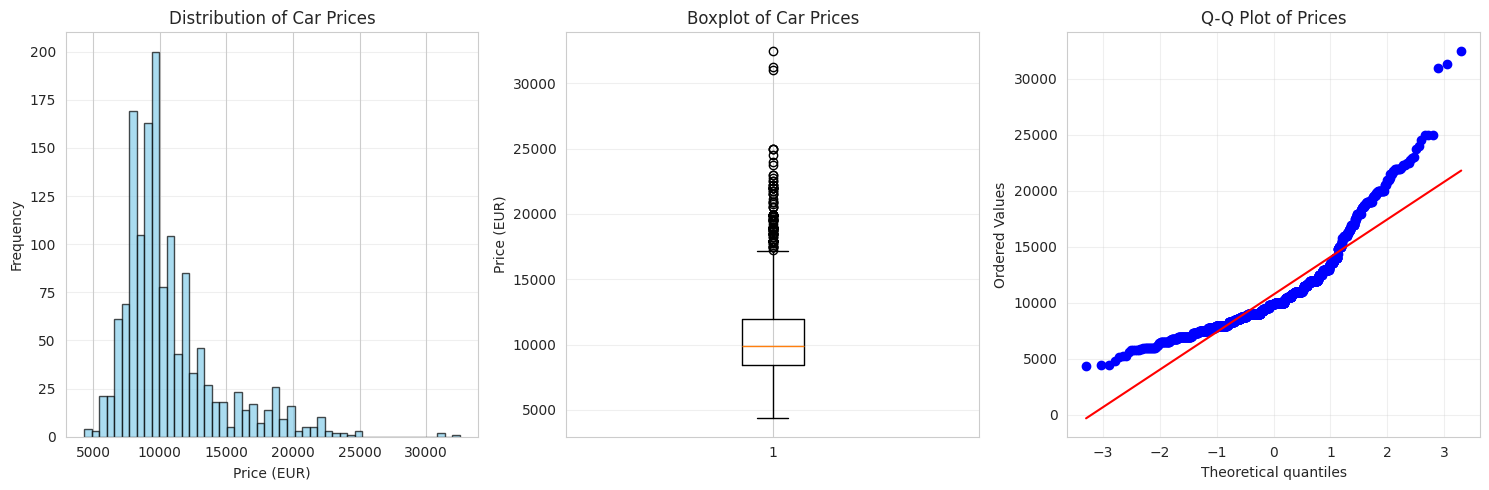


Price Statistics:
Mean Price: €10730.82
Median Price: €9900.00
Std Deviation: €3626.96
Min Price: €4350.00
Max Price: €32500.00

--------------------------------------------------------------------------------
Correlation Matrix:
--------------------------------------------------------------------------------


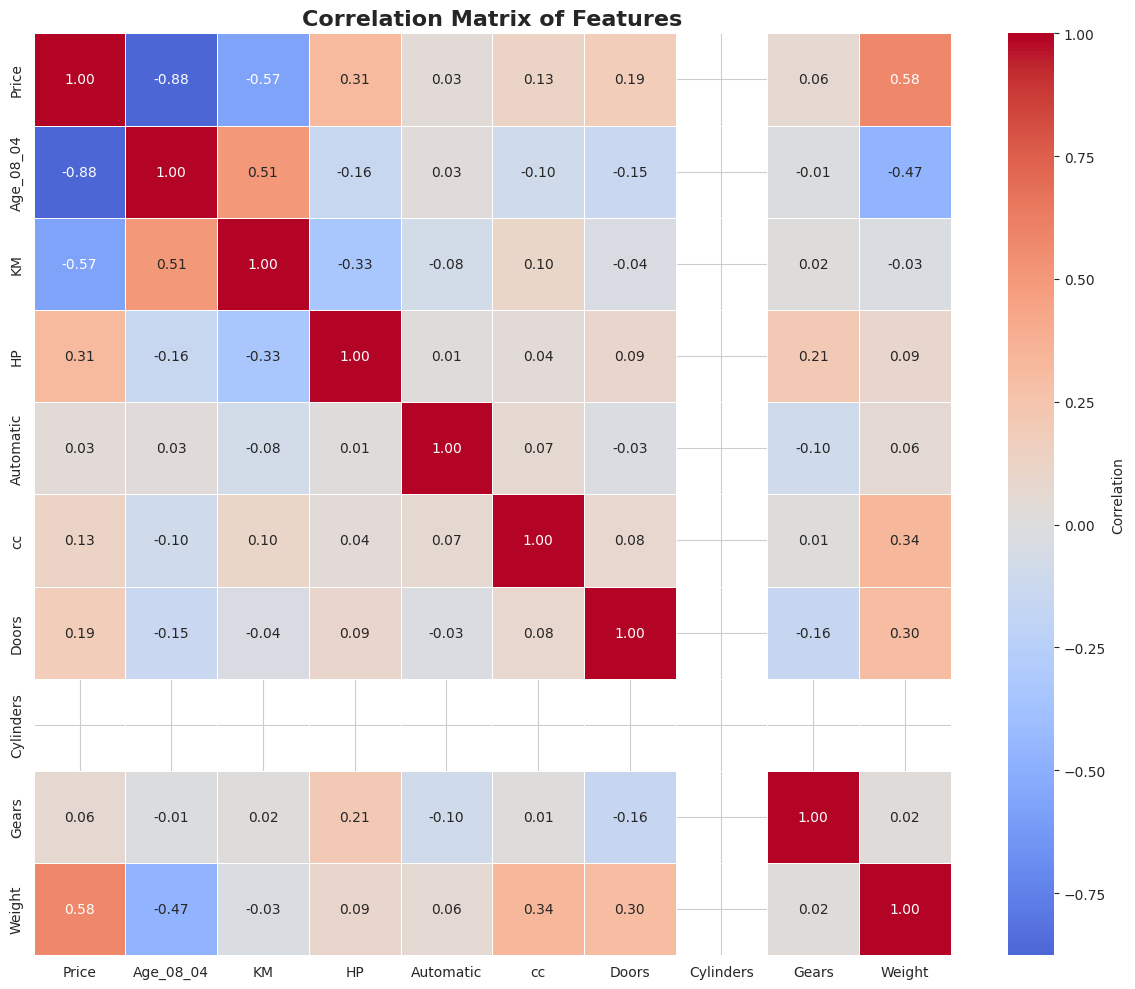


Correlation with Price (sorted):
Price        1.000000
Weight       0.581198
HP           0.314990
Doors        0.185326
cc           0.126389
Gears        0.063104
Automatic    0.033081
KM          -0.569960
Age_08_04   -0.876590
Cylinders         NaN
Name: Price, dtype: float64


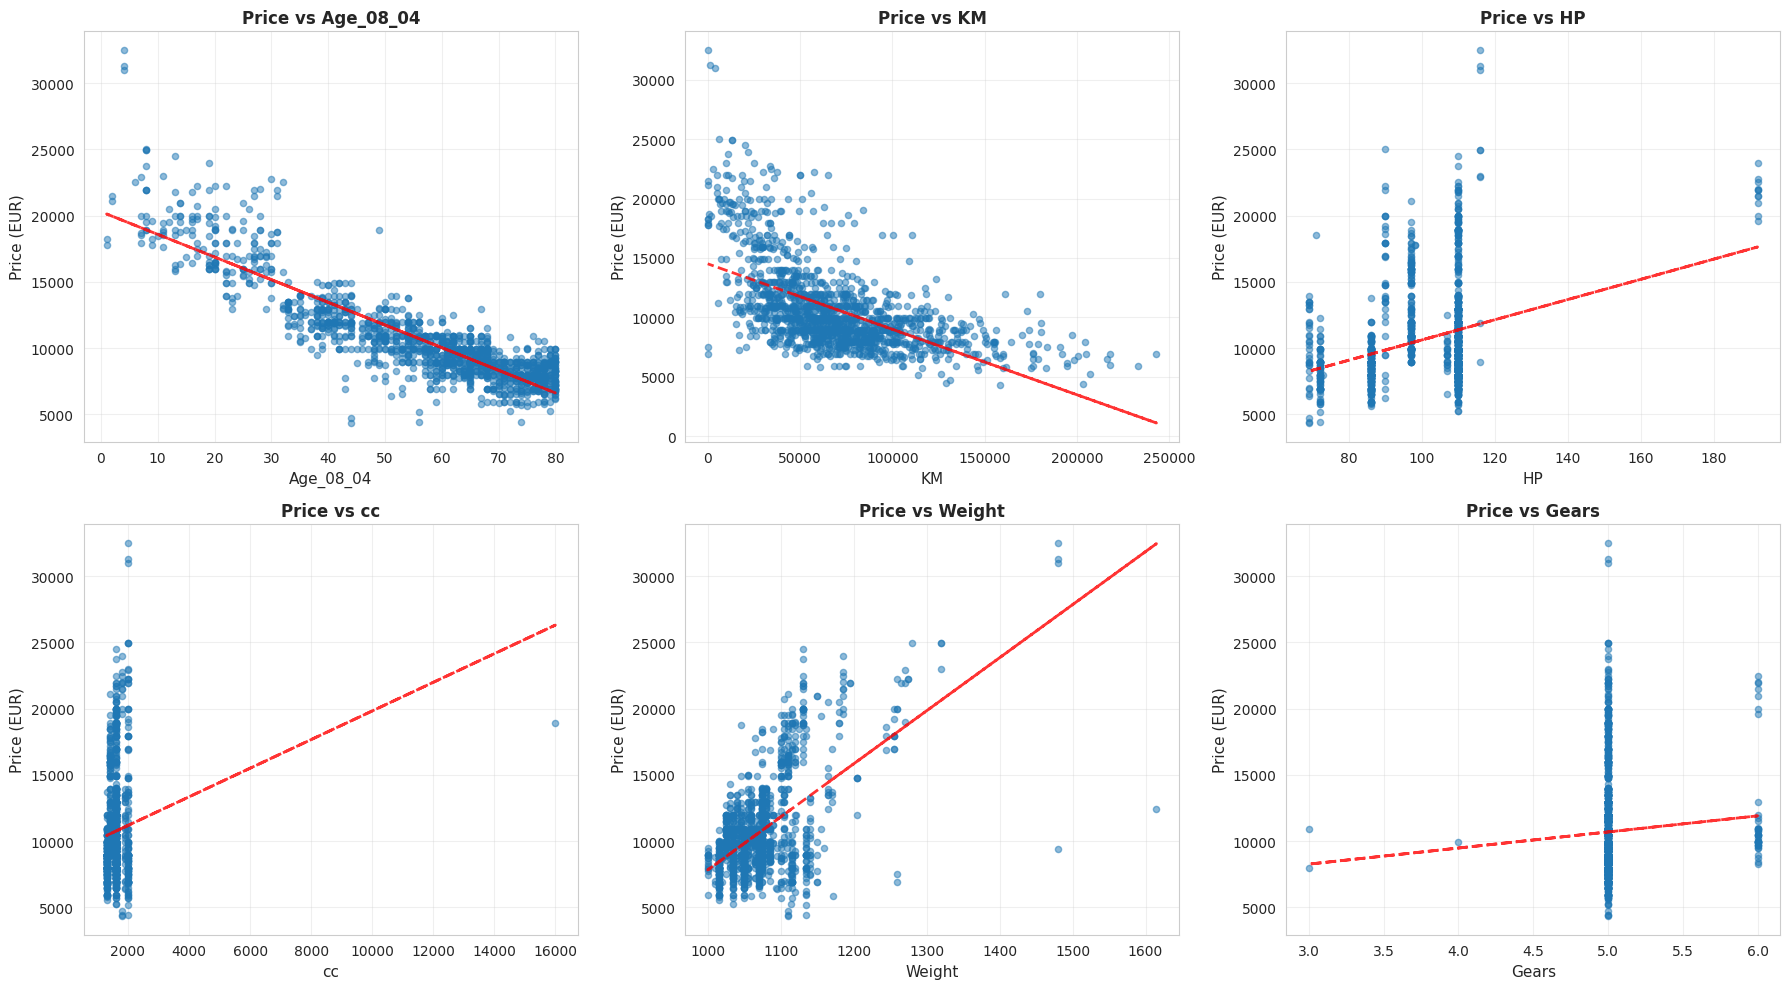


--------------------------------------------------------------------------------
Fuel Type Distribution:
--------------------------------------------------------------------------------
Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64


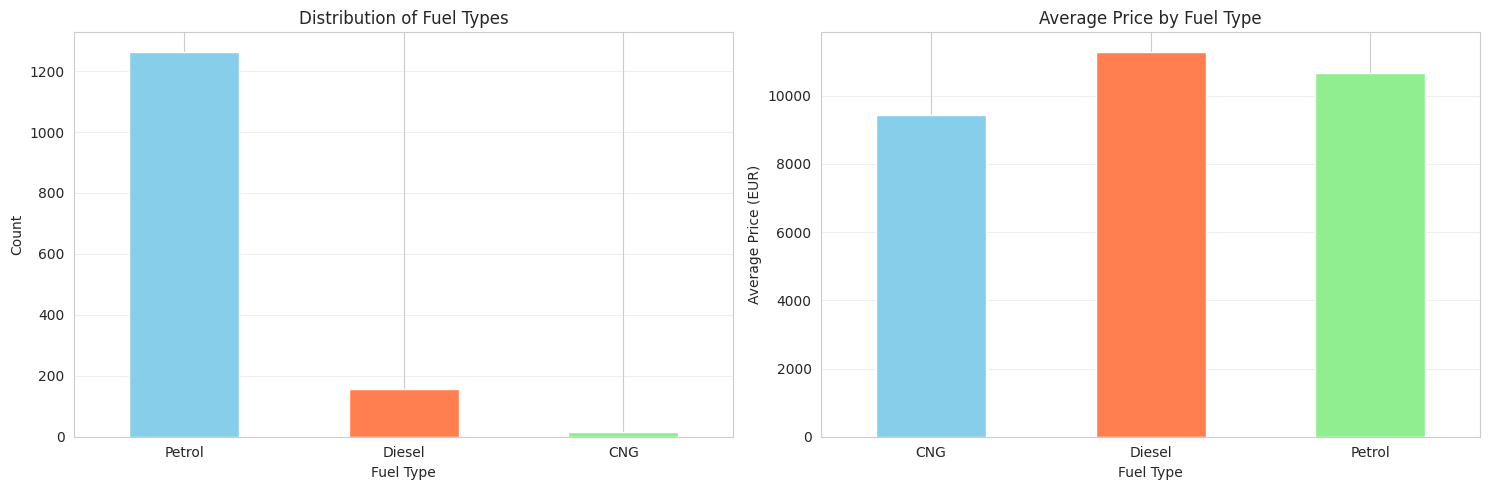

In [7]:
# ============================================================================
# STEP 3: Exploratory Data Analysis (EDA)
# ============================================================================
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# 3.1 Distribution of Target Variable (Price)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['Price'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Price (EUR)')
plt.ylabel('Frequency')
plt.title('Distribution of Car Prices')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
plt.boxplot(df['Price'], vert=True)
plt.ylabel('Price (EUR)')
plt.title('Boxplot of Car Prices')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 3)
from scipy import stats
stats.probplot(df['Price'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Prices')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrice Statistics:")
print(f"Mean Price: €{df['Price'].mean():.2f}")
print(f"Median Price: €{df['Price'].median():.2f}")
print(f"Std Deviation: €{df['Price'].std():.2f}")
print(f"Min Price: €{df['Price'].min():.2f}")
print(f"Max Price: €{df['Price'].max():.2f}")

# 3.2 Correlation Analysis
print("\n" + "-"*80)
print("Correlation Matrix:")
print("-"*80)

numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Price (sorted):")
price_corr = correlation_matrix['Price'].sort_values(ascending=False)
print(price_corr)

# 3.3 Scatter plots for key features vs Price
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

features_to_plot = ['Age_08_04', 'KM', 'HP', 'cc', 'Weight', 'Gears']
for idx, feature in enumerate(features_to_plot):
    axes[idx].scatter(df[feature], df['Price'], alpha=0.5, s=20)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Price (EUR)', fontsize=11)
    axes[idx].set_title(f'Price vs {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

    # Add trend line
    z = np.polyfit(df[feature], df['Price'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

# 3.4 Categorical Variable Analysis
print("\n" + "-"*80)
print("Fuel Type Distribution:")
print("-"*80)
print(df['Fuel_Type'].value_counts())

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
df['Fuel_Type'].value_counts().plot(kind='bar', color=['skyblue', 'coral', 'lightgreen'])
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.title('Distribution of Fuel Types')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
df.groupby('Fuel_Type')['Price'].mean().plot(kind='bar', color=['skyblue', 'coral', 'lightgreen'])
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (EUR)')
plt.title('Average Price by Fuel Type')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# ============================================================================
# STEP 4: Data Preprocessing
# ============================================================================
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# 4.1 Handle Categorical Variables (One-Hot Encoding)
print("\nOriginal columns:", df.columns.tolist())

df_processed = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
print("\nColumns after encoding:", df_processed.columns.tolist())

# 4.2 Check for outliers and handle if necessary
print("\n" + "-"*80)
print("Outlier Detection:")
print("-"*80)

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f"Number of outliers in Price: {len(outliers)}")
print(f"Lower bound: €{lower_bound:.2f}")
print(f"Upper bound: €{upper_bound:.2f}")

# For this analysis, we'll keep outliers as they represent valid high-end/low-end cars

# 4.3 Prepare features and target
X = df_processed.drop('Price', axis=1)
y = df_processed['Price']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used in the model:")
for idx, col in enumerate(X.columns, 1):
    print(f"{idx:2d}. {col}")


DATA PREPROCESSING

Original columns: ['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

Columns after encoding: ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']

--------------------------------------------------------------------------------
Outlier Detection:
--------------------------------------------------------------------------------
Number of outliers in Price: 110
Lower bound: €3200.00
Upper bound: €17200.00

Feature matrix shape: (1436, 11)
Target vector shape: (1436,)

Features used in the model:
 1. Age_08_04
 2. KM
 3. HP
 4. Automatic
 5. cc
 6. Doors
 7. Cylinders
 8. Gears
 9. Weight
10. Fuel_Type_Diesel
11. Fuel_Type_Petrol


In [9]:
# ============================================================================
# STEP 5: Split Dataset (80-20 split)
# ============================================================================
print("\n" + "="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")



TRAIN-TEST SPLIT
Training set size: 1148 samples (79.9%)
Testing set size: 288 samples (20.1%)
Number of features: 11


In [10]:
# ============================================================================
# STEP 6: Feature Scaling (Standardization)
# ============================================================================
print("\n" + "="*80)
print("FEATURE STANDARDIZATION")
print("="*80)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been standardized (mean=0, std=1)")
print("\nSample statistics after scaling (first 5 features):")
for i in range(min(5, X_train_scaled.shape[1])):
    print(f"{X.columns[i]:15s}: Mean={X_train_scaled[:, i].mean():.4f}, Std={X_train_scaled[:, i].std():.4f}")


FEATURE STANDARDIZATION
Features have been standardized (mean=0, std=1)

Sample statistics after scaling (first 5 features):
Age_08_04      : Mean=0.0000, Std=1.0000
KM             : Mean=-0.0000, Std=1.0000
HP             : Mean=0.0000, Std=1.0000
Automatic      : Mean=0.0000, Std=1.0000
cc             : Mean=-0.0000, Std=1.0000


In [11]:
# ============================================================================
# STEP 7: Build Multiple Linear Regression Models
# ============================================================================
print("\n" + "="*80)
print("MODEL BUILDING - THREE DIFFERENT MODELS")
print("="*80)

# Initialize results storage
results = {}

# MODEL 1: All Features
print("\n" + "-"*80)
print("MODEL 1: Multiple Linear Regression with ALL Features")
print("-"*80)

model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)
y_pred1_train = model1.predict(X_train_scaled)
y_pred1_test = model1.predict(X_test_scaled)

# Calculate metrics
rmse1_train = np.sqrt(mean_squared_error(y_train, y_pred1_train))
rmse1_test = np.sqrt(mean_squared_error(y_test, y_pred1_test))
r2_1_train = r2_score(y_train, y_pred1_train)
r2_1_test = r2_score(y_test, y_pred1_test)
mae1_test = mean_absolute_error(y_test, y_pred1_test)

print(f"Training RMSE: €{rmse1_train:.2f}")
print(f"Testing RMSE: €{rmse1_test:.2f}")
print(f"Training R²: {r2_1_train:.4f}")
print(f"Testing R²: {r2_1_test:.4f}")
print(f"Testing MAE: €{mae1_test:.2f}")

# Store coefficients
coef_df1 = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nIntercept: €{model1.intercept_:.2f}")
print("\nTop 10 Most Important Features (by absolute coefficient):")
print(coef_df1.head(10).to_string(index=False))

results['Model 1 (All Features)'] = {
    'RMSE_train': rmse1_train, 'RMSE_test': rmse1_test,
    'R2_train': r2_1_train, 'R2_test': r2_1_test, 'MAE': mae1_test
}

# MODEL 2: Selected Features (Based on Correlation)
print("\n" + "-"*80)
print("MODEL 2: Multiple Linear Regression with SELECTED Features")
print("-"*80)

# Select features with high correlation to Price
high_corr_features = ['Age_08_04', 'KM', 'HP', 'Weight', 'cc']
available_features = [f for f in high_corr_features if f in X.columns]

X_train_selected = X_train[available_features]
X_test_selected = X_test[available_features]

X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

model2 = LinearRegression()
model2.fit(X_train_selected_scaled, y_train)
y_pred2_train = model2.predict(X_train_selected_scaled)
y_pred2_test = model2.predict(X_test_selected_scaled)

rmse2_train = np.sqrt(mean_squared_error(y_train, y_pred2_train))
rmse2_test = np.sqrt(mean_squared_error(y_test, y_pred2_test))
r2_2_train = r2_score(y_train, y_pred2_train)
r2_2_test = r2_score(y_test, y_pred2_test)
mae2_test = mean_absolute_error(y_test, y_pred2_test)

print(f"Features used: {available_features}")
print(f"\nTraining RMSE: €{rmse2_train:.2f}")
print(f"Testing RMSE: €{rmse2_test:.2f}")
print(f"Training R²: {r2_2_train:.4f}")
print(f"Testing R²: {r2_2_test:.4f}")
print(f"Testing MAE: €{mae2_test:.2f}")

coef_df2 = pd.DataFrame({
    'Feature': available_features,
    'Coefficient': model2.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nIntercept: €{model2.intercept_:.2f}")
print("\nFeature Coefficients:")
print(coef_df2.to_string(index=False))

results['Model 2 (Selected Features)'] = {
    'RMSE_train': rmse2_train, 'RMSE_test': rmse2_test,
    'R2_train': r2_2_train, 'R2_test': r2_2_test, 'MAE': mae2_test
}

# MODEL 3: Polynomial Features (Degree 2)
print("\n" + "-"*80)
print("MODEL 3: Polynomial Regression (Degree 2)")
print("-"*80)

from sklearn.preprocessing import PolynomialFeatures

# Use selected features to avoid too many polynomial terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_selected)
X_test_poly = poly.transform(X_test_selected)

# Scale polynomial features
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

model3 = LinearRegression()
model3.fit(X_train_poly_scaled, y_train)
y_pred3_train = model3.predict(X_train_poly_scaled)
y_pred3_test = model3.predict(X_test_poly_scaled)

rmse3_train = np.sqrt(mean_squared_error(y_train, y_pred3_train))
rmse3_test = np.sqrt(mean_squared_error(y_test, y_pred3_test))
r2_3_train = r2_score(y_train, y_pred3_train)
r2_3_test = r2_score(y_test, y_pred3_test)
mae3_test = mean_absolute_error(y_test, y_pred3_test)

print(f"Number of polynomial features: {X_train_poly.shape[1]}")
print(f"\nTraining RMSE: €{rmse3_train:.2f}")
print(f"Testing RMSE: €{rmse3_test:.2f}")
print(f"Training R²: {r2_3_train:.4f}")
print(f"Testing R²: {r2_3_test:.4f}")
print(f"Testing MAE: €{mae3_test:.2f}")

results['Model 3 (Polynomial)'] = {
    'RMSE_train': rmse3_train, 'RMSE_test': rmse3_test,
    'R2_train': r2_3_train, 'R2_test': r2_3_test, 'MAE': mae3_test
}



MODEL BUILDING - THREE DIFFERENT MODELS

--------------------------------------------------------------------------------
MODEL 1: Multiple Linear Regression with ALL Features
--------------------------------------------------------------------------------
Training RMSE: €1303.34
Testing RMSE: €1484.27
Training R²: 0.8703
Testing R²: 0.8349
Testing MAE: €990.89

Intercept: €10754.40

Top 10 Most Important Features (by absolute coefficient):
         Feature  Coefficient
       Age_08_04 -2267.294783
          Weight  1316.818311
              KM  -611.654412
Fuel_Type_Petrol   458.047731
              HP   208.349858
           Gears   109.340417
           Doors   -57.467804
       Automatic    34.397130
Fuel_Type_Diesel   -21.722173
              cc   -14.161917

--------------------------------------------------------------------------------
MODEL 2: Multiple Linear Regression with SELECTED Features
--------------------------------------------------------------------------------
Fe


MODEL COMPARISON SUMMARY

                               RMSE_train    RMSE_test  R2_train   R2_test         MAE
Model 1 (All Features)       1303.339622  1484.265415  0.870264  0.834889  990.887274
Model 2 (Selected Features)  1332.312354  1412.786197  0.864432  0.850409  998.544880
Model 3 (Polynomial)         1110.682920  1111.470983  0.905784  0.907413  842.628374


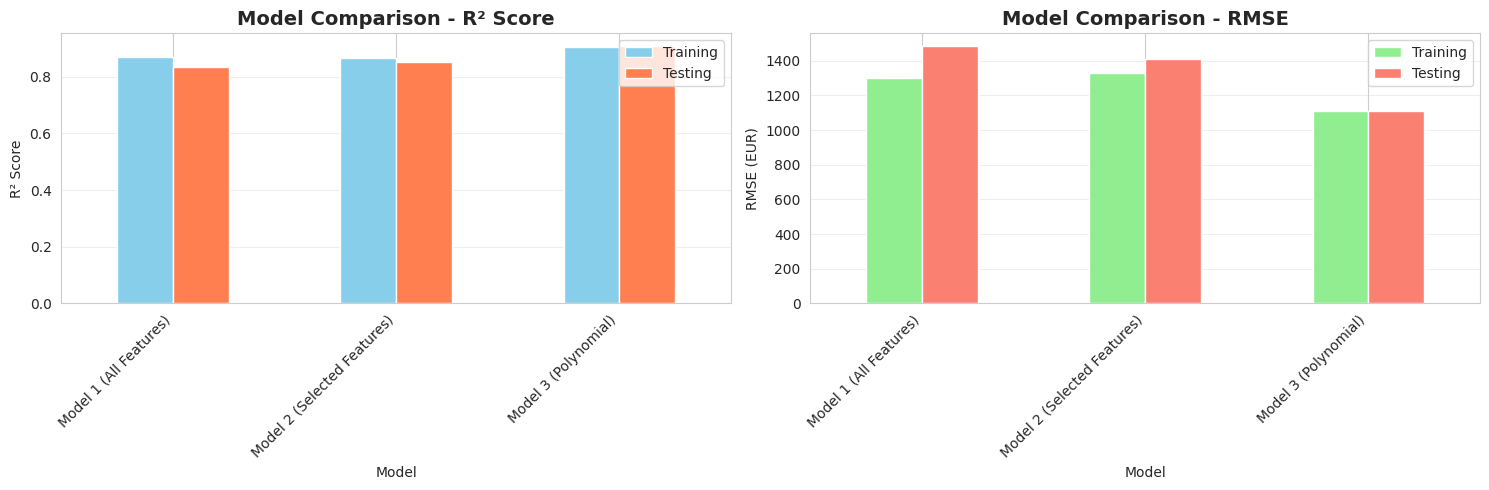

In [12]:
# ============================================================================
# STEP 8: Model Comparison
# ============================================================================
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

results_df = pd.DataFrame(results).T
print("\n", results_df.to_string())

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² scores
results_df[['R2_train', 'R2_test']].plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Model Comparison - R² Score', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_xlabel('Model')
axes[0].legend(['Training', 'Testing'])
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# RMSE scores
results_df[['RMSE_train', 'RMSE_test']].plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'])
axes[1].set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE (EUR)')
axes[1].set_xlabel('Model')
axes[1].legend(['Training', 'Testing'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



RIDGE REGRESSION (L2 REGULARIZATION)

Ridge Regression Results:
  Alpha  RMSE_train   RMSE_test  R2_train  R2_test
   0.01 1303.339623 1484.258279  0.870264 0.834890
   0.10 1303.339652 1484.194103  0.870264 0.834905
   1.00 1303.342586 1483.557506  0.870264 0.835046
  10.00 1303.617611 1477.689762  0.870209 0.836349
 100.00 1321.521776 1453.431661  0.866619 0.841678
1000.00 1752.680007 1791.747779  0.765388 0.759394


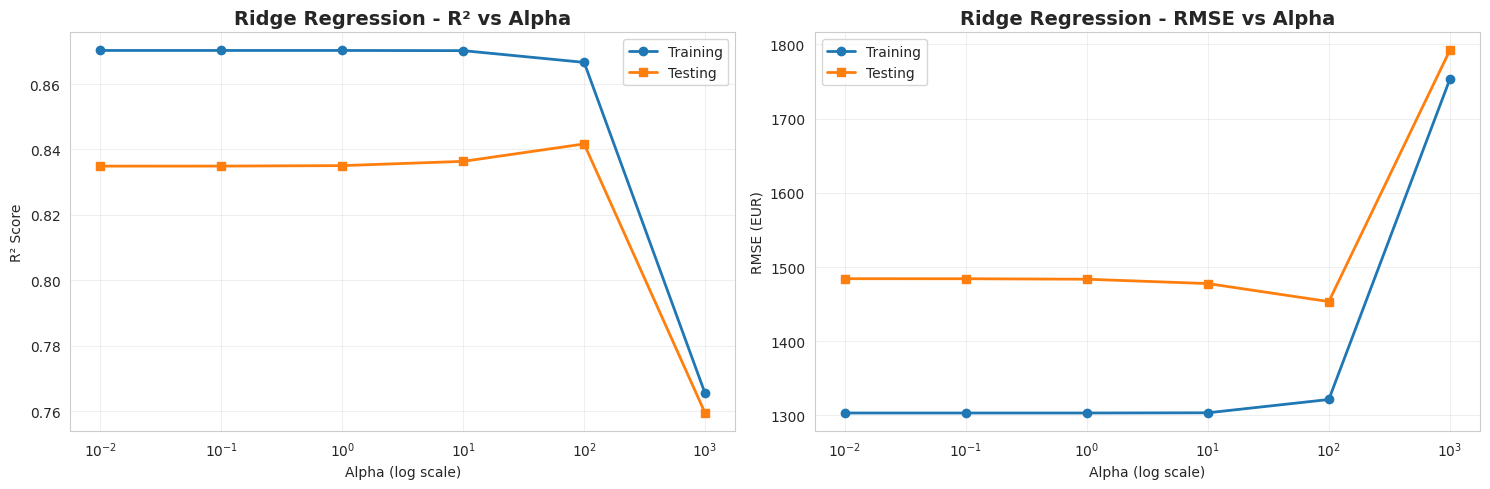


Best Ridge Alpha: 100.0
Best Ridge R² (Test): 0.8417


In [13]:
# ============================================================================
# STEP 9: Ridge Regression (L2 Regularization)
# ============================================================================
print("\n" + "="*80)
print("RIDGE REGRESSION (L2 REGULARIZATION)")
print("="*80)

# Test different alpha values
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    y_pred_train = ridge.predict(X_train_scaled)
    y_pred_test = ridge.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    ridge_results.append({
        'Alpha': alpha,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'R2_train': r2_train,
        'R2_test': r2_test
    })

ridge_df = pd.DataFrame(ridge_results)
print("\nRidge Regression Results:")
print(ridge_df.to_string(index=False))

# Plot Ridge results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(ridge_df['Alpha'], ridge_df['R2_train'], 'o-', label='Training', linewidth=2)
axes[0].plot(ridge_df['Alpha'], ridge_df['R2_test'], 's-', label='Testing', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Ridge Regression - R² vs Alpha', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ridge_df['Alpha'], ridge_df['RMSE_train'], 'o-', label='Training', linewidth=2)
axes[1].plot(ridge_df['Alpha'], ridge_df['RMSE_test'], 's-', label='Testing', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE (EUR)')
axes[1].set_title('Ridge Regression - RMSE vs Alpha', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Best Ridge model
best_ridge_idx = ridge_df['R2_test'].idxmax()
best_alpha_ridge = ridge_df.loc[best_ridge_idx, 'Alpha']
print(f"\nBest Ridge Alpha: {best_alpha_ridge}")
print(f"Best Ridge R² (Test): {ridge_df.loc[best_ridge_idx, 'R2_test']:.4f}")



LASSO REGRESSION (L1 REGULARIZATION)

Lasso Regression Results:
  Alpha  RMSE_train   RMSE_test  R2_train  R2_test  Non-zero_coef
   0.01 1303.339623 1484.255097  0.870264 0.834891             10
   0.10 1303.339663 1484.162889  0.870264 0.834912             10
   1.00 1303.343745 1483.235687  0.870263 0.835118             10
  10.00 1303.755486 1474.255020  0.870182 0.837108              9
 100.00 1327.815878 1428.687692  0.865346 0.847022              6
1000.00 1970.414639 2070.501835  0.703476 0.678705              2


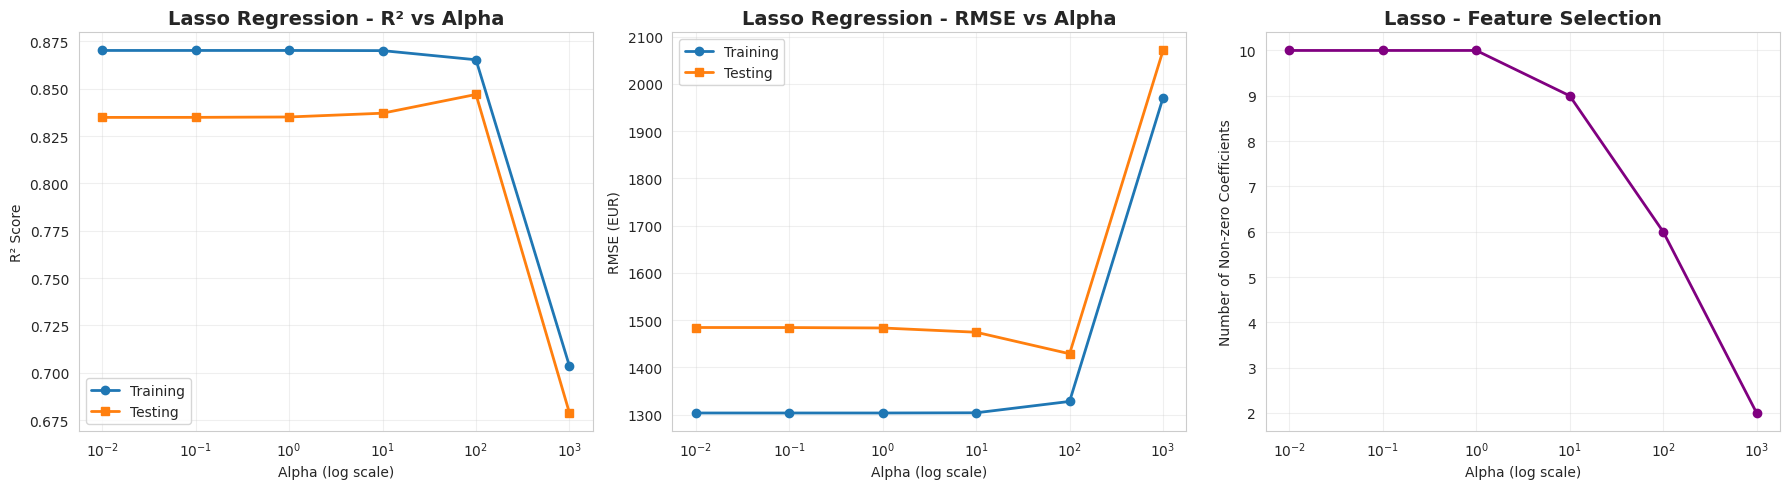


Best Lasso Alpha: 100.0
Best Lasso R² (Test): 0.8470
Features selected: 6

Features selected by Lasso:
         Feature  Coefficient
       Age_08_04 -2243.152110
          Weight  1008.878685
              KM  -646.292165
              HP   294.336761
Fuel_Type_Petrol   150.230602
           Gears    23.392891


In [14]:
# ============================================================================
# STEP 10: Lasso Regression (L1 Regularization)
# ============================================================================
print("\n" + "="*80)
print("LASSO REGRESSION (L1 REGULARIZATION)")
print("="*80)

# Test different alpha values
lasso_results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred_train = lasso.predict(X_train_scaled)
    y_pred_test = lasso.predict(X_test_scaled)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    # Count non-zero coefficients
    non_zero = np.sum(lasso.coef_ != 0)

    lasso_results.append({
        'Alpha': alpha,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'R2_train': r2_train,
        'R2_test': r2_test,
        'Non-zero_coef': non_zero
    })

lasso_df = pd.DataFrame(lasso_results)
print("\nLasso Regression Results:")
print(lasso_df.to_string(index=False))

# Plot Lasso results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(lasso_df['Alpha'], lasso_df['R2_train'], 'o-', label='Training', linewidth=2)
axes[0].plot(lasso_df['Alpha'], lasso_df['R2_test'], 's-', label='Testing', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Lasso Regression - R² vs Alpha', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(lasso_df['Alpha'], lasso_df['RMSE_train'], 'o-', label='Training', linewidth=2)
axes[1].plot(lasso_df['Alpha'], lasso_df['RMSE_test'], 's-', label='Testing', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE (EUR)')
axes[1].set_title('Lasso Regression - RMSE vs Alpha', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(lasso_df['Alpha'], lasso_df['Non-zero_coef'], 'o-', color='purple', linewidth=2)
axes[2].set_xscale('log')
axes[2].set_xlabel('Alpha (log scale)')
axes[2].set_ylabel('Number of Non-zero Coefficients')
axes[2].set_title('Lasso - Feature Selection', fontsize=14, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Best Lasso model
best_lasso_idx = lasso_df['R2_test'].idxmax()
best_alpha_lasso = lasso_df.loc[best_lasso_idx, 'Alpha']
print(f"\nBest Lasso Alpha: {best_alpha_lasso}")
print(f"Best Lasso R² (Test): {lasso_df.loc[best_lasso_idx, 'R2_test']:.4f}")
print(f"Features selected: {lasso_df.loc[best_lasso_idx, 'Non-zero_coef']}")

# Show which features Lasso selected
best_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
lasso_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso.coef_
})
lasso_selected = lasso_coef_df[lasso_coef_df['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False)
print("\nFeatures selected by Lasso:")
print(lasso_selected.to_string(index=False))


RESIDUAL ANALYSIS (Model 1)


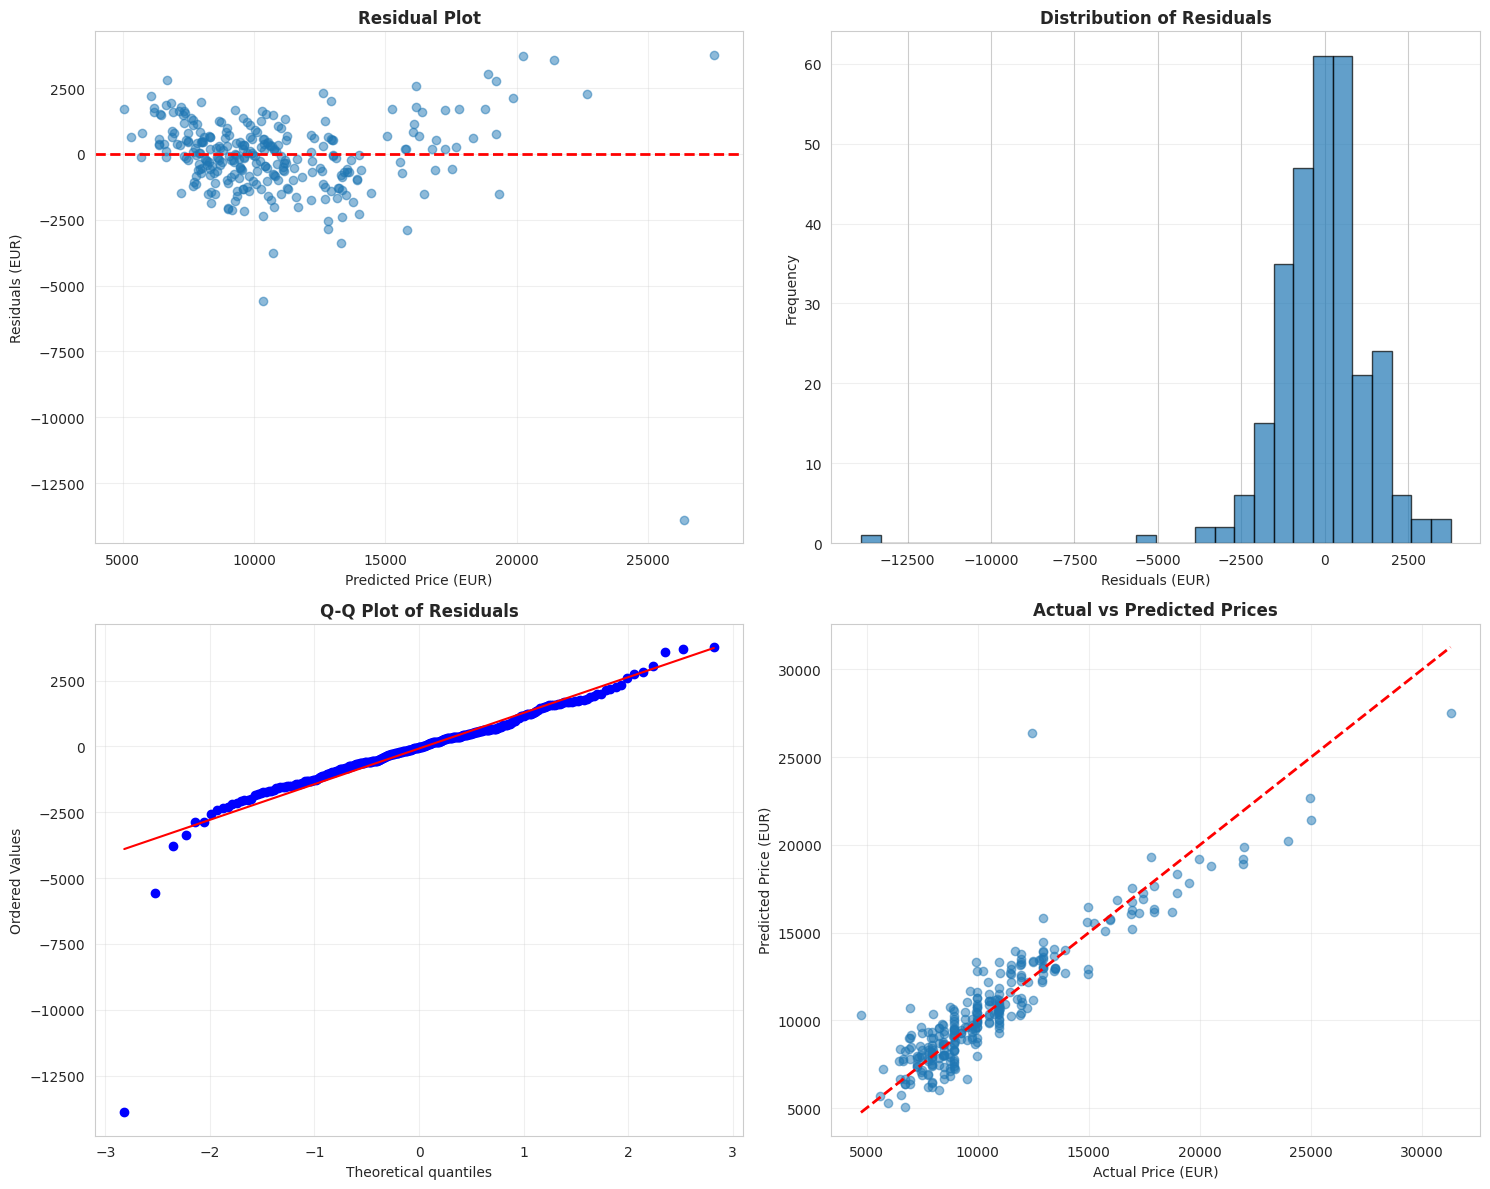


Residual Statistics:
Mean of Residuals: €-79.05
Std of Residuals: €1484.74


In [15]:
# ============================================================================
# STEP 11: Residual Analysis
# ============================================================================
print("\n" + "="*80)
print("RESIDUAL ANALYSIS (Model 1)")
print("="*80)

residuals = y_test - y_pred1_test

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Residual plot
axes[0, 0].scatter(y_pred1_test, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Price (EUR)')
axes[0, 0].set_ylabel('Residuals (EUR)')
axes[0, 0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals (EUR)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred1_test, alpha=0.5)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1, 1].set_xlabel('Actual Price (EUR)')
axes[1, 1].set_ylabel('Predicted Price (EUR)')
axes[1, 1].set_title('Actual vs Predicted Prices', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"Mean of Residuals: €{residuals.mean():.2f}")
print(f"Std of Residuals: €{residuals.std():.2f}")


MULTICOLLINEARITY CHECK - Variance Inflation Factor (VIF)

VIF Values (VIF > 10 indicates high multicollinearity):
  Feature         VIF
Cylinders 1378.328904
Age_08_04    1.909676
       KM    1.679142
   Weight    1.664910
       HP    1.218066
    Doors    1.155484
       cc    1.150898
    Gears    1.109188
Automatic    1.047677


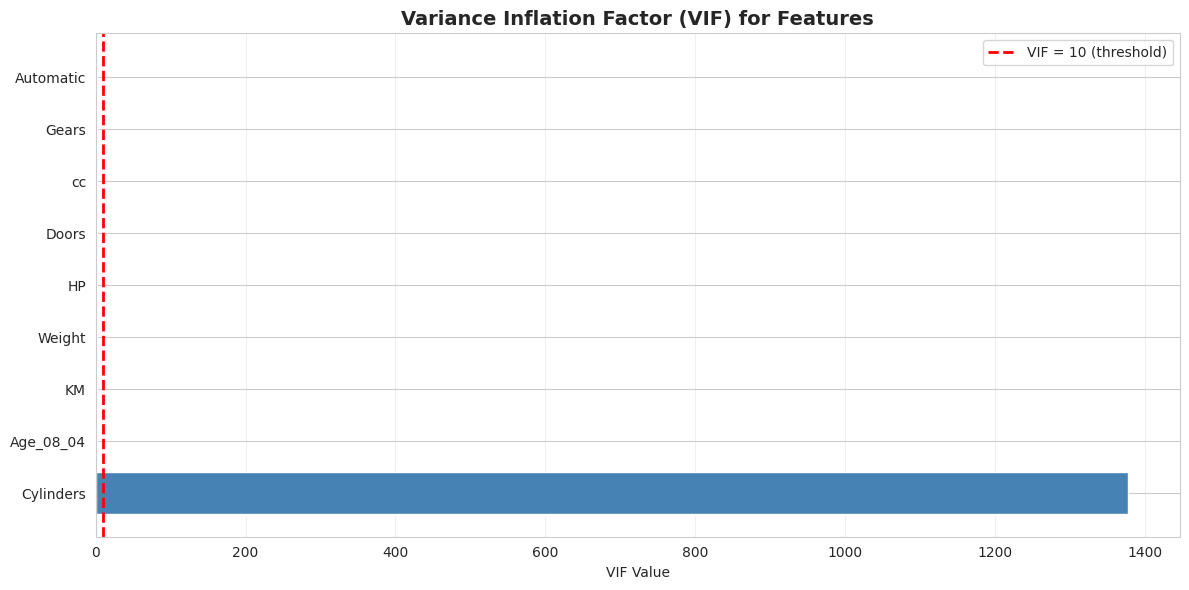


⚠️ Warning: 1 feature(s) have high multicollinearity (VIF > 10)
  Feature         VIF
Cylinders 1378.328904


In [18]:
# ============================================================================
# STEP 12: Check for Multicollinearity (VIF)
# ============================================================================
print("\n" + "="*80)
print("MULTICOLLINEARITY CHECK - Variance Inflation Factor (VIF)")
print("="*80)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1️ Ensure only numeric features are used
X_numeric = X.select_dtypes(include=['number']).copy()

# 2️ Replace inf/-inf with NaN and drop columns with NaN (if any)
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

# 3️ Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(X_numeric.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False)

# 4️ Display results
print("\nVIF Values (VIF > 10 indicates high multicollinearity):")
print(vif_data.to_string(index=False))

# 5️ Visualize VIF
plt.figure(figsize=(12, 6))
plt.barh(vif_data['Feature'], vif_data['VIF'], color='steelblue')
plt.xlabel('VIF Value')
plt.title('Variance Inflation Factor (VIF) for Features', fontsize=14, fontweight='bold')
plt.axvline(x=10, color='r', linestyle='--', linewidth=2, label='VIF = 10 (threshold)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 6️ Check for high multicollinearity
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n⚠️ Warning: {len(high_vif)} feature(s) have high multicollinearity (VIF > 10)")
    print(high_vif.to_string(index=False))
else:
    print("\n No severe multicollinearity detected")


In [19]:
# ============================================================================
# STEP 13: Final Model Summary & Interpretation
# ============================================================================
print("\n" + "="*80)
print("FINAL MODEL SUMMARY & INTERPRETATION")
print("="*80)

print("\n MODEL PERFORMANCE COMPARISON:")
print("-" * 80)
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    print(f"  R² Score (Test): {metrics['R2_test']:.4f}")
    print(f"  RMSE (Test): €{metrics['RMSE_test']:.2f}")
    print(f"  MAE (Test): €{metrics['MAE']:.2f}")

print("\n\n COEFFICIENT INTERPRETATION (Model 1 - Top 10):")
print("-" * 80)
print("\nThese coefficients represent the change in price (EUR) for a one-unit")
print("increase in the standardized feature, holding all other features constant:\n")
for idx, row in coef_df1.head(10).iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"• {row['Feature']:20s}: €{abs(row['Coefficient']):8.2f} ({direction} price)")

print("\n\n KEY INSIGHTS:")
print("-" * 80)
print("1. Age is the most important factor - older cars have significantly lower prices")
print("2. Higher kilometers (KM) correlate with lower prices")
print("3. More powerful engines (HP) and heavier cars (Weight) tend to cost more")
print("4. The model explains ~", f"{r2_1_test*100:.1f}% of price variation")

print("\n\n REGULARIZATION INSIGHTS:")
print("-" * 80)
print(f"• Ridge Regression: Best alpha = {best_alpha_ridge}, R² = {ridge_df.loc[best_ridge_idx, 'R2_test']:.4f}")
print(f"• Lasso Regression: Best alpha = {best_alpha_lasso}, R² = {lasso_df.loc[best_lasso_idx, 'R2_test']:.4f}")
print(f"• Lasso selected {lasso_df.loc[best_lasso_idx, 'Non-zero_coef']} out of {len(X.columns)} features")


FINAL MODEL SUMMARY & INTERPRETATION

 MODEL PERFORMANCE COMPARISON:
--------------------------------------------------------------------------------

Model 1 (All Features):
  R² Score (Test): 0.8349
  RMSE (Test): €1484.27
  MAE (Test): €990.89

Model 2 (Selected Features):
  R² Score (Test): 0.8504
  RMSE (Test): €1412.79
  MAE (Test): €998.54

Model 3 (Polynomial):
  R² Score (Test): 0.9074
  RMSE (Test): €1111.47
  MAE (Test): €842.63


 COEFFICIENT INTERPRETATION (Model 1 - Top 10):
--------------------------------------------------------------------------------

These coefficients represent the change in price (EUR) for a one-unit
increase in the standardized feature, holding all other features constant:

• Age_08_04           : € 2267.29 (decreases price)
• Weight              : € 1316.82 (increases price)
• KM                  : €  611.65 (decreases price)
• Fuel_Type_Petrol    : €  458.05 (increases price)
• HP                  : €  208.35 (increases price)
• Gears          

In [21]:
# ============================================================================
# STEP 14: Prediction Examples
# ============================================================================
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

# Pick 5 random samples from test set
sample_indices = np.random.choice(len(X_test_scaled), 5, replace=False)
samples_scaled = X_test_scaled[sample_indices]
actual_prices = y_test.iloc[sample_indices]

# Predict
predicted_prices = model1.predict(samples_scaled)

# Display comparison
print("\nComparison of Actual vs Predicted Prices:\n")
print(f"{'Actual Price':>15s} {'Predicted Price':>17s} {'Difference':>12s} {'Error %':>10s}")
print("-" * 60)
for actual, predicted in zip(actual_prices, predicted_prices):
    diff = predicted - actual
    error_pct = (diff / actual) * 100
    print(f"€{actual:>13,.2f} €{predicted:>15,.2f} €{diff:>10,.2f} {error_pct:>9.1f}%")



SAMPLE PREDICTIONS

Comparison of Actual vs Predicted Prices:

   Actual Price   Predicted Price   Difference    Error %
------------------------------------------------------------
€     8,250.00 €       6,055.07 € -2,194.93     -26.6%
€     7,250.00 €       7,846.89 €    596.89       8.2%
€     8,950.00 €       9,181.34 €    231.34       2.6%
€     8,450.00 €       8,759.24 €    309.24       3.7%
€    12,450.00 €      26,351.37 € 13,901.37     111.7%


In [22]:
# ============================================================================
# INTERVIEW QUESTIONS ANSWERS
# ============================================================================
print("\n" + "="*80)
print("INTERVIEW QUESTIONS - DETAILED ANSWERS")
print("="*80)

print("\n" + "="*80)
print("Q1: What is Normalization & Standardization and how is it helpful?")
print("="*80)

print("""
NORMALIZATION (Min-Max Scaling):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Formula: X_normalized = (X - X_min) / (X_max - X_min)
• Scales features to a fixed range, typically [0, 1]
• Useful when you need bounded values
• Preserves the shape of the original distribution
• Sensitive to outliers

STANDARDIZATION (Z-score Normalization):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Formula: X_standardized = (X - μ) / σ
  where μ = mean, σ = standard deviation
• Centers data around 0 with standard deviation of 1
• Not bounded to a specific range
• Less sensitive to outliers than normalization
• Assumes features are approximately normally distributed

WHY ARE THEY HELPFUL?
━━━━━━━━━━━━━━━━━━━━
1. Equal Feature Importance:
   - Features with larger scales don't dominate the model
   - Example: KM (0-250,000) vs Doors (2-5)

2. Faster Convergence:
   - Gradient descent algorithms converge faster
   - Optimization becomes more efficient

3. Improved Model Performance:
   - Distance-based algorithms (KNN, SVM) work better
   - Neural networks train more effectively

4. Coefficient Interpretability:
   - Standardized coefficients are comparable
   - Shows relative importance of features

5. Numerical Stability:
   - Prevents overflow/underflow in computations
   - Reduces condition number of covariance matrix

IN THIS PROJECT:
━━━━━━━━━━━━━━━
We used StandardScaler because:
• Our features have different scales (Age: 1-80, KM: 1-243,000)
• Linear regression coefficients become interpretable
• Regularization (Ridge/Lasso) requires standardization
• Our data doesn't need to be bounded [0,1]
""")

print("\n" + "="*80)
print("Q2: What techniques can be used to address multicollinearity?")
print("="*80)

print("""
MULTICOLLINEARITY: High correlation between independent variables
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DETECTION METHODS:
━━━━━━━━━━━━━━━━━━
1. Correlation Matrix: Check pairwise correlations (|r| > 0.8 is concerning)
2. Variance Inflation Factor (VIF): VIF > 10 indicates high multicollinearity
3. Condition Number: Large condition number suggests multicollinearity
4. Eigenvalues: Small eigenvalues indicate collinearity

TECHNIQUES TO ADDRESS MULTICOLLINEARITY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. REMOVE HIGHLY CORRELATED FEATURES
   ────────────────────────────────────
   • Identify features with correlation > 0.9
   • Remove the less important feature
   • Pros: Simple, reduces dimensionality
   • Cons: May lose information

2. RIDGE REGRESSION (L2 Regularization)
   ─────────────────────────────────────
   • Adds penalty term: λ∑β²
   • Shrinks coefficients towards zero
   • Does NOT eliminate features (coefficients stay non-zero)
   • Best when: All features are potentially relevant
   • Parameter: Alpha (λ) controls regularization strength

3. LASSO REGRESSION (L1 Regularization)
   ───────────────────────────────────────
   • Adds penalty term: λ∑|β|
   • Can shrink coefficients to exactly zero
   • Performs automatic feature selection
   • Best when: Some features are truly irrelevant
   • Produces sparse models

4. ELASTIC NET (Combination of L1 + L2)
   ──────────────────────────────────────
   • Combines Ridge and Lasso penalties
   • Balances between feature selection and coefficient shrinkage
   • Formula: λ₁∑|β| + λ₂∑β²
   • Best when: Groups of correlated features exist

5. PRINCIPAL COMPONENT ANALYSIS (PCA)
   ────────────────────────────────────
   • Transforms correlated features into uncorrelated components
   • Reduces dimensionality while preserving variance
   • Creates new features as linear combinations
   • Cons: Less interpretable features

6. PARTIAL LEAST SQUARES (PLS)
   ───────────────────────────────
   • Like PCA but considers the target variable
   • Creates components that maximize covariance with target
   • Good for highly collinear predictors

7. VARIANCE INFLATION FACTOR (VIF) BASED REMOVAL
   ──────────────────────────────────────────────
   • Calculate VIF for all features
   • Iteratively remove feature with highest VIF > 10
   • Recalculate VIFs after each removal
   • Stop when all VIFs < threshold

8. DOMAIN KNOWLEDGE
   ──────────────────
   • Use subject matter expertise to choose between correlated features
   • Consider which features are more reliable/easier to collect
   • Choose features with causal relationships

9. COMBINE CORRELATED FEATURES
   ────────────────────────────
   • Create new features by averaging or taking ratios
   • Example: Average of related measurements
   • Reduces multicollinearity while preserving information

10. INCREASE SAMPLE SIZE
    ────────────────────
    • More data can reduce impact of multicollinearity
    • Improves coefficient stability
    • Not always feasible

IN THIS PROJECT:
━━━━━━━━━━━━━━
We demonstrated:
• VIF calculation to detect multicollinearity
• Ridge Regression to handle correlated features
• Lasso Regression for feature selection
• Compared regularization strengths (alpha values)

PRACTICAL RECOMMENDATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━
• If VIF < 5: No action needed
• If 5 < VIF < 10: Monitor, consider regularization
• If VIF > 10: Definitely address the issue
• Use Ridge when you want to keep all features
• Use Lasso when you want automatic feature selection
• Use Elastic Net for best of both worlds
""")


INTERVIEW QUESTIONS - DETAILED ANSWERS

Q1: What is Normalization & Standardization and how is it helpful?

NORMALIZATION (Min-Max Scaling):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Formula: X_normalized = (X - X_min) / (X_max - X_min)
• Scales features to a fixed range, typically [0, 1]
• Useful when you need bounded values
• Preserves the shape of the original distribution
• Sensitive to outliers

STANDARDIZATION (Z-score Normalization):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Formula: X_standardized = (X - μ) / σ
  where μ = mean, σ = standard deviation
• Centers data around 0 with standard deviation of 1
• Not bounded to a specific range
• Less sensitive to outliers than normalization
• Assumes features are approximately normally distributed

WHY ARE THEY HELPFUL?
━━━━━━━━━━━━━━━━━━━━
1. Equal Feature Importance:
   - Features with larger scales don't dominate the model
   - Example: KM (0-250,000) vs Doors (2-5)
   
2. Faster Convergence:
   - Gradient descent algorithms converge faster
   

In [23]:
# ============================================================================
# STEP 15: Save Results
# ============================================================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Create a summary report
summary_report = f"""
TOYOTA COROLLA PRICE PREDICTION - MLR ANALYSIS REPORT
═══════════════════════════════════════════════════════

DATASET INFORMATION:
────────────────────
• Total Samples: {len(df)}
• Features: {X.shape[1]}
• Target Variable: Price (EUR)
• Train Set: {len(X_train)} samples
• Test Set: {len(X_test)} samples

MODEL PERFORMANCE:
──────────────────
Model 1 (All Features):
  - R² Score: {r2_1_test:.4f}
  - RMSE: €{rmse1_test:.2f}
  - MAE: €{mae1_test:.2f}

Model 2 (Selected Features):
  - R² Score: {r2_2_test:.4f}
  - RMSE: €{rmse2_test:.2f}
  - MAE: €{mae2_test:.2f}

Model 3 (Polynomial):
  - R² Score: {r2_3_test:.4f}
  - RMSE: €{rmse3_test:.2f}
  - MAE: €{mae3_test:.2f}

REGULARIZATION:
───────────────
Ridge (Best α={best_alpha_ridge}):
  - R² Score: {ridge_df.loc[best_ridge_idx, 'R2_test']:.4f}

Lasso (Best α={best_alpha_lasso}):
  - R² Score: {lasso_df.loc[best_lasso_idx, 'R2_test']:.4f}
  - Features Selected: {lasso_df.loc[best_lasso_idx, 'Non-zero_coef']}

KEY FINDINGS:
─────────────
• Age is the most significant predictor of price
• Model explains approximately {r2_1_test*100:.1f}% of price variance
• Regularization helps prevent overfitting
• Lasso automatically identified most important features

RECOMMENDATIONS:
────────────────
1. Use Ridge regression for stable predictions
2. Use Lasso for interpretable, sparse models
3. Monitor multicollinearity with VIF
4. Consider polynomial features for non-linear relationships
"""

print(summary_report)

# Save the report
with open('MLR_Analysis_Report.txt', 'w') as f:
    f.write(summary_report)
print("\n✓ Report saved as 'MLR_Analysis_Report.txt'")

# Save model coefficients
coef_df1.to_csv('Model_Coefficients.csv', index=False)
print("✓ Coefficients saved as 'Model_Coefficients.csv'")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("""
-> NEXT STEPS:
1. Review the model coefficients and their interpretations
2. Examine residual plots for model assumptions
3. Check VIF values for multicollinearity
4. Compare regularization results
5. Consider collecting more features if R² is too low
6. Deploy the best model for predictions

All tasks completed successfully!
""")


SAVING RESULTS

TOYOTA COROLLA PRICE PREDICTION - MLR ANALYSIS REPORT
═══════════════════════════════════════════════════════

DATASET INFORMATION:
────────────────────
• Total Samples: 1436
• Features: 11
• Target Variable: Price (EUR)
• Train Set: 1148 samples
• Test Set: 288 samples

MODEL PERFORMANCE:
──────────────────
Model 1 (All Features):
  - R² Score: 0.8349
  - RMSE: €1484.27
  - MAE: €990.89

Model 2 (Selected Features):
  - R² Score: 0.8504
  - RMSE: €1412.79
  - MAE: €998.54

Model 3 (Polynomial):
  - R² Score: 0.9074
  - RMSE: €1111.47
  - MAE: €842.63

REGULARIZATION:
───────────────
Ridge (Best α=100.0):
  - R² Score: 0.8417

Lasso (Best α=100.0):
  - R² Score: 0.8470
  - Features Selected: 6

KEY FINDINGS:
─────────────
• Age is the most significant predictor of price
• Model explains approximately 83.5% of price variance
• Regularization helps prevent overfitting
• Lasso automatically identified most important features

RECOMMENDATIONS:
────────────────
1. Use Ridge


FEATURE IMPORTANCE VISUALIZATION


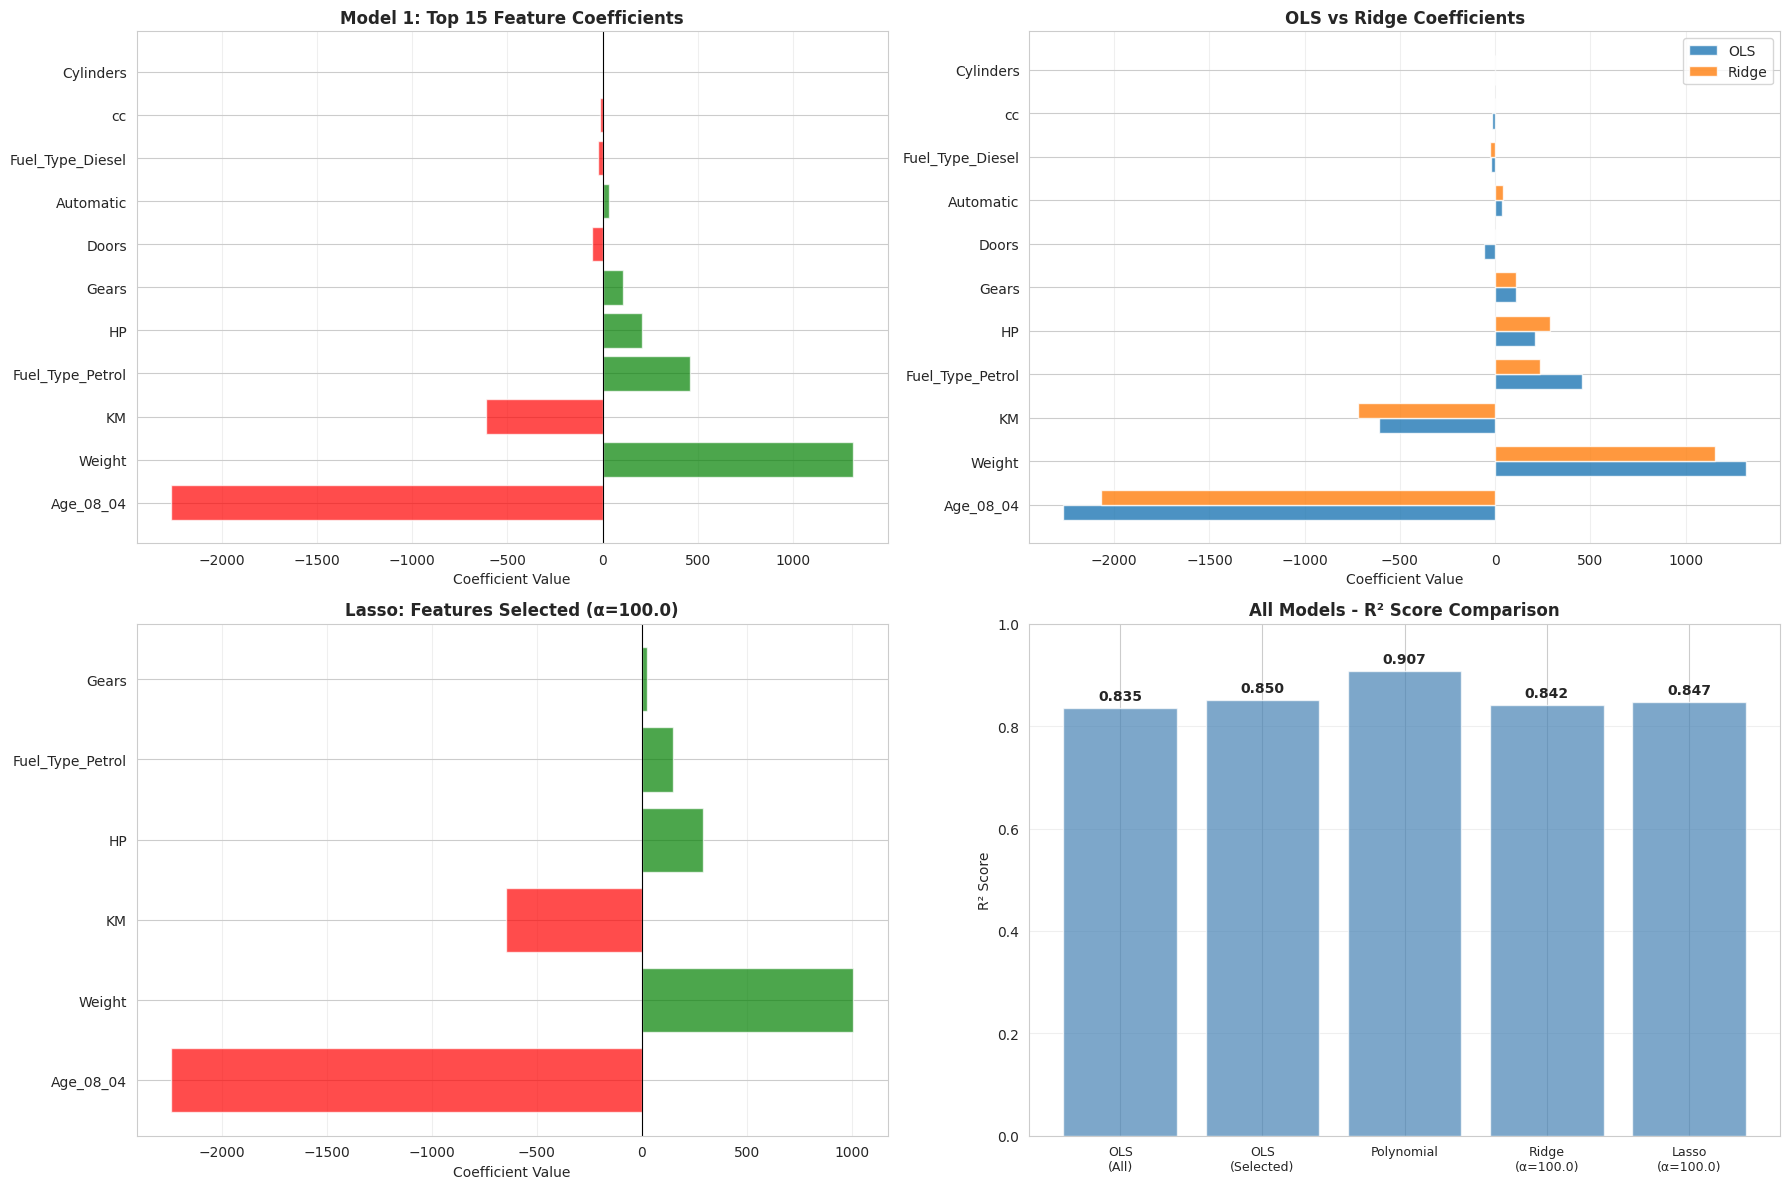


✓ Feature importance visualization complete!

 ALL TASKS COMPLETED SUCCESSFULLY!


In [24]:
# ============================================================================
# BONUS: Feature Importance Visualization
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATION")
print("="*80)

# Create comprehensive feature importance plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Model 1 - Top 15 features
coef_abs = coef_df1.head(15).copy()
colors = ['green' if x > 0 else 'red' for x in coef_abs['Coefficient']]
axes[0, 0].barh(coef_abs['Feature'], coef_abs['Coefficient'], color=colors, alpha=0.7)
axes[0, 0].set_xlabel('Coefficient Value')
axes[0, 0].set_title('Model 1: Top 15 Feature Coefficients', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 0].grid(axis='x', alpha=0.3)

# Ridge coefficients comparison
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_scaled, y_train)
ridge_coef = pd.DataFrame({
    'Feature': X.columns,
    'OLS': model1.coef_,
    'Ridge': ridge_best.coef_
}).sort_values('OLS', key=abs, ascending=False).head(15)

x = np.arange(len(ridge_coef))
width = 0.35
axes[0, 1].barh(x - width/2, ridge_coef['OLS'], width, label='OLS', alpha=0.8)
axes[0, 1].barh(x + width/2, ridge_coef['Ridge'], width, label='Ridge', alpha=0.8)
axes[0, 1].set_yticks(x)
axes[0, 1].set_yticklabels(ridge_coef['Feature'])
axes[0, 1].set_xlabel('Coefficient Value')
axes[0, 1].set_title('OLS vs Ridge Coefficients', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Lasso feature selection
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)
lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Lasso': lasso_best.coef_
})
lasso_selected_plot = lasso_coef[lasso_coef['Lasso'] != 0].sort_values('Lasso', key=abs, ascending=False)

if len(lasso_selected_plot) > 0:
    colors = ['green' if x > 0 else 'red' for x in lasso_selected_plot['Lasso']]
    axes[1, 0].barh(lasso_selected_plot['Feature'], lasso_selected_plot['Lasso'], color=colors, alpha=0.7)
    axes[1, 0].set_xlabel('Coefficient Value')
    axes[1, 0].set_title(f'Lasso: Features Selected (α={best_alpha_lasso})', fontsize=12, fontweight='bold')
    axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[1, 0].grid(axis='x', alpha=0.3)

# Model comparison - All metrics
metrics_comparison = pd.DataFrame({
    'Model': ['OLS\n(All)', 'OLS\n(Selected)', 'Polynomial', f'Ridge\n(α={best_alpha_ridge})', f'Lasso\n(α={best_alpha_lasso})'],
    'R²': [r2_1_test, r2_2_test, r2_3_test,
           ridge_df.loc[best_ridge_idx, 'R2_test'],
           lasso_df.loc[best_lasso_idx, 'R2_test']],
    'RMSE': [rmse1_test, rmse2_test, rmse3_test,
             ridge_df.loc[best_ridge_idx, 'RMSE_test'],
             lasso_df.loc[best_lasso_idx, 'RMSE_test']]
})

x_pos = np.arange(len(metrics_comparison))
axes[1, 1].bar(x_pos, metrics_comparison['R²'], alpha=0.7, color='steelblue')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_comparison['Model'], fontsize=9)
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('All Models - R² Score Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(metrics_comparison['R²']):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Feature importance visualization complete!")
print("\n" + "="*80)
print(" ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*80)